<a href="https://colab.research.google.com/github/ritheshp-18/DEEP-LEARNING---24BAD098/blob/main/exp_2_dl_part_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training with optimizer: SGD
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6373 - loss: 1.3962 - val_accuracy: 0.8402 - val_loss: 0.6975
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8529 - loss: 0.5781 - val_accuracy: 0.8855 - val_loss: 0.4418
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8826 - loss: 0.4341 - val_accuracy: 0.8992 - val_loss: 0.3688
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8945 - loss: 0.3782 - val_accuracy: 0.9076 - val_loss: 0.3328
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9027 - loss: 0.3462 - val_accuracy: 0.9133 - val_loss: 0.3108
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9085 - loss: 0.3244 - val_accuracy: 0.9178 - val_loss: 0.2942
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9131 - loss: 0.3072 - val_accuracy: 0.9208 - val_loss: 0.2817
Epoch 8/10
375/375 ━━━━

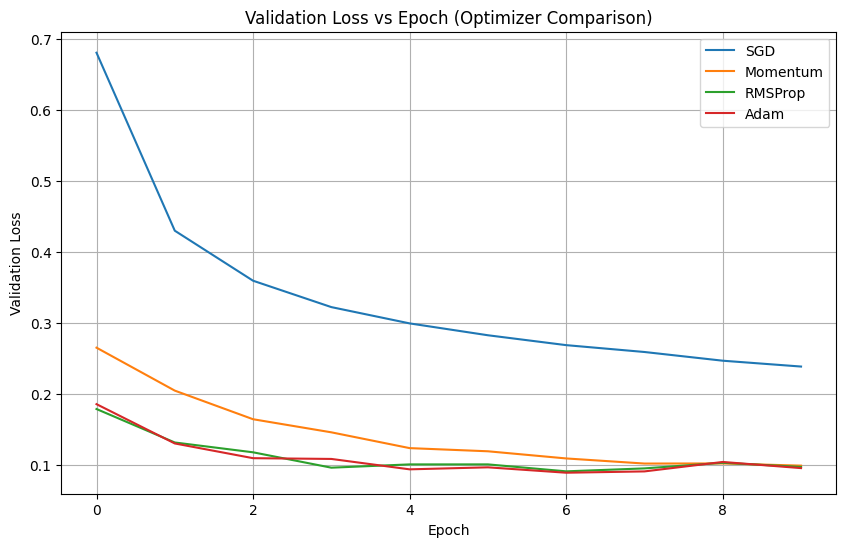

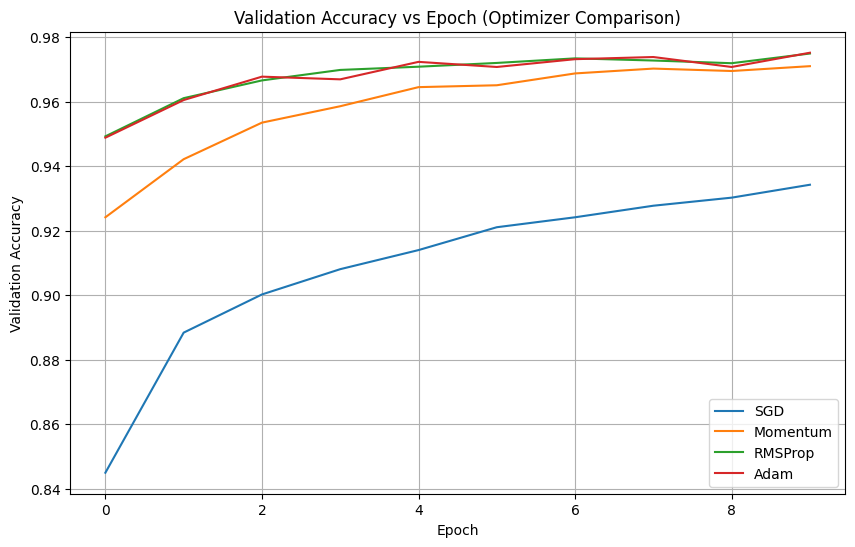

SGD: Final Val Accuracy = 0.9342, Final Val Loss = 0.2382
Momentum: Final Val Accuracy = 0.9710, Final Val Loss = 0.0985
RMSProp: Final Val Accuracy = 0.9749, Final Val Loss = 0.0967
Adam: Final Val Accuracy = 0.9752, Final Val Loss = 0.0950


In [7]:
# NAME : RITHESH P Roll No: 24BAD098
import tensorflow as tf
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
import matplotlib.pyplot as plt
# Roll No: <YOUR_ROLL_NUMBER>
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


def build_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': RMSprop(learning_rate=0.001),
    'Adam': Adam(learning_rate=0.001)
}

opt_history = {}

for name, opt in optimizers.items():
    print(f"\nTraining with optimizer: {name}")
    model = build_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                         validation_split=0.2, verbose=1)
    opt_history[name] = history


def build_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': RMSprop(learning_rate=0.001),
    'Adam': Adam(learning_rate=0.001)
}

opt_history = {}

for name, opt in optimizers.items():
    print(f"\nTraining with optimizer: {name}")
    model = build_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                         validation_split=0.2, verbose=1)
    opt_history[name] = history

# Loss vs Epoch
plt.figure(figsize=(10, 6))
for name in optimizers:
    plt.plot(opt_history[name].history['val_loss'], label=name)
plt.title('Validation Loss vs Epoch (Optimizer Comparison)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('optimizer_loss_comparison.png')
plt.show()

# Accuracy vs Epoch
plt.figure(figsize=(10, 6))
for name in optimizers:
    plt.plot(opt_history[name].history['val_accuracy'], label=name)
plt.title('Validation Accuracy vs Epoch (Optimizer Comparison)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('optimizer_accuracy_comparison.png')
plt.show()

for name in optimizers:
    final_acc = opt_history[name].history['val_accuracy'][-1]
    final_loss = opt_history[name].history['val_loss'][-1]
    print(f"{name}: Final Val Accuracy = {final_acc:.4f}, Final Val Loss = {final_loss:.4f}")